In [1]:
!pip install nltk
!pip install Sastrawi
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
import emoji
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk

**BACA DATA 1**

In [3]:
data_path = 'instagram (berwarna) rabu 08.30.csv'
df = pd.read_csv(data_path)

In [4]:
# Mengecek jumlah row & coloumn
print(f'shape: {df.shape}')

shape: (1031, 5)


**CLEANING DUPLICATE**

In [5]:
# Cek jumlah nilai duplikat di kolom 'akun'
duplicates = df['user'].duplicated(keep=False)  # semua duplikat (termasuk yang pertama)
print(f"Jumlah baris dengan nilai duplikat di 'user': {duplicates.sum()}")

# Tampilkan contoh duplikat
print("\nContoh baris dengan nilai duplikat:")
print(df[duplicates].head(10))

Jumlah baris dengan nilai duplikat di 'user': 230

Contoh baris dengan nilai duplikat:
                                     link user              user  \
0           https://www.instagram.com/awbimax/           awbimax   
1          https://www.instagram.com/meysna__/          meysna__   
2     https://www.instagram.com/choqi_isyraqi/     choqi_isyraqi   
3       https://www.instagram.com/deasyfillah/       deasyfillah   
4  https://www.instagram.com/pendakiindonesia/  pendakiindonesia   
5     https://www.instagram.com/anindythaarsa/     anindythaarsa   
6        https://www.instagram.com/fianiadila/        fianiadila   
7         https://www.instagram.com/yogitaama/         yogitaama   
8           https://www.instagram.com/ekorore/           ekorore   
9        https://www.instagram.com/rdhrmdhn11/        rdhrmdhn11   

  waktu posting                                              komen  \
0           11h                                      Caper banget!   
1            6h         

In [6]:
# Baca data
df = pd.read_csv('instagram (berwarna) rabu 08.30.csv')

# Hapus duplikat berdasarkan kolom 'akun' — simpan baris pertama
df_clean = df.drop_duplicates(subset=['user'], keep='first')

# Tampilkan info
print(f"Sebelum: {len(df)} baris")
print(f"Sesudah: {len(df_clean)} baris")
print(f"Jumlah duplikat dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('cleaning duplicate instagram1.csv', index=False)

Sebelum: 1031 baris
Sesudah: 896 baris
Jumlah duplikat dihapus: 135


**BENERIN TANGGAL PUBLISH**

In [16]:
import pandas as pd
from datetime import datetime, timedelta
import re

# Baca data
df = pd.read_csv('cleaning duplicate instagram1.csv')

# Referensi: 3 Desember 2025 pukul 08:30
reference_datetime = datetime(2025, 12, 3, 8, 30)

def convert_relative_time(time_str):
    if pd.isna(time_str) or not isinstance(time_str, str):
        return 'Invalid Date'
    try:
        s = time_str.strip().lower()
        match = re.match(r'^(\d+)\s*([hd])$', s)
        if not match:
            return 'Invalid Date'
        number = int(match.group(1))
        unit = match.group(2)
        if unit == 'h':
            dt = reference_datetime - timedelta(hours=number)
        elif unit == 'd':
            dt = reference_datetime - timedelta(days=number)
        else:
            return 'Invalid Date'
        return dt.strftime('%Y-%m-%d')
    except:
        return 'Invalid Date'

# Konversi
df['tanggal_absolut'] = df['waktu posting'].apply(convert_relative_time)

# Ganti 'Invalid Date' (opsional)
df['tanggal_absolut'] = df['tanggal_absolut'].replace('Invalid Date', '2025-12-01')

# 🔥 HAPUS KOLOM ASLI 'waktu'
df = df.drop(columns=['waktu posting'])

# Simpan
df.to_csv('instagram1_preprocessed_waktu.csv', index=False)

# Menampilkan beberapa hasil untuk verifikasi
print("Sample of preprocessed data:")
print(df.head())

Sample of preprocessed data:
                                     link user              user  \
0           https://www.instagram.com/awbimax/           awbimax   
1          https://www.instagram.com/meysna__/          meysna__   
2     https://www.instagram.com/choqi_isyraqi/     choqi_isyraqi   
3       https://www.instagram.com/deasyfillah/       deasyfillah   
4  https://www.instagram.com/pendakiindonesia/  pendakiindonesia   

                                               komen        likes  \
0                                      Caper banget!    667 likes   
1                                       Preeeetttttt     51 likes   
2  Mau tanya, kalau jadi pejabat kan ada cek kese...  1,038 likes   
3           Pak kita udh pinter pa…. Bapa yang belum     29 likes   
4               Hidupmu tenang pak? Tenteram? Yakin?    430 likes   

  tanggal_absolut  
0      2025-12-02  
1      2025-12-03  
2      2025-12-02  
3      2025-12-03  
4      2025-12-02  


**BENERIN JUMLAH LIKE/VIEW**

In [22]:
import pandas as pd
import re

# Baca dataset (ganti nama file sesuai kebutuhan)
df = pd.read_csv('instagram1_preprocessed_waktu.csv')  # ← pastikan file ini ada!

def convert_likes(likes_str):
    if pd.isna(likes_str) or not isinstance(likes_str, str):
        return 0

    print(f"Processing: '{likes_str}'")

    try:
        # Normalisasi: lowercase dan strip spasi
        s = likes_str.strip().lower()

        # Hapus kata 'likes' atau 'like'
        s = re.sub(r'\s*likes?\s*', '', s).strip()

        # Jika masih ada koma, ganti dengan titik (jika koma digunakan sebagai desimal)
        # Tapi untuk "1,038", kita ingin hapus koma (pemisah ribuan)
        if ',' in s and '.' not in s:
            # Asumsikan koma adalah pemisah ribuan → hapus semua koma
            s = s.replace(',', '')
        elif ',' in s and '.' in s:
            # Ada koma dan titik — mungkin koma adalah desimal → ganti koma jadi titik
            s = s.replace(',', '.')

        # Ekstrak hanya digit dan titik (untuk angka desimal)
        cleaned = re.sub(r'[^\d.]', '', s)
        if not cleaned or cleaned == '.':
            return 0

        # Konversi ke float, lalu int
        number = int(float(cleaned))

        return number

    except Exception as e:
        print(f"Error converting '{likes_str}': {e}")
        return 0

# Terapkan ke kolom 'likes'
df['likes'] = df['likes'].apply(convert_likes)

# Simpan hasil
df.to_csv('instagram1_cleaned_likes.csv', index=False)

# Tampilkan hasil
print("Sample of cleaned likes:")
print(df.head(10))

Processing: '667 likes'
Processing: '51 likes'
Processing: '1,038 likes'
Processing: '29 likes'
Processing: '430 likes'
Processing: '23 likes'
Processing: '36 likes'
Processing: '25 likes'
Processing: '36 likes'
Processing: '700 likes'
Processing: '500 likes'
Processing: '413 likes'
Processing: '4 likes'
Processing: '760 likes'
Processing: '145 likes'
Processing: '413 likes'
Processing: '97 likes'
Processing: '204 likes'
Processing: '175 likes'
Processing: '484 likes'
Processing: '26 likes'
Processing: '260 likes'
Processing: '1 like'
Processing: '59 likes'
Processing: '7 likes'
Processing: '5 likes'
Processing: '8 likes'
Processing: '1 like'
Processing: '30 likes'
Processing: '11 likes'
Processing: '49 likes'
Processing: '1 like'
Processing: '1 like'
Processing: 'Reply'
Processing: 'Reply'
Processing: '1 like'
Processing: '1 like'
Processing: '1 like'
Processing: '1 like'
Processing: '1 like'
Processing: '4 likes'
Processing: '18 likes'
Processing: '2 likes'
Processing: '19 likes'
Pro

**PREPOCESSING DATA (HAPUS EMOJI & KECILKAN HURUF)**

In [23]:
# Fungsi untuk menghapus emoji
def remove_emoji(text):
    if isinstance(text, str):  # Check if the text is a string before processing
        return emoji.replace_emoji(text, replace='')
    else:
        return text  # Return the original value if it's not a string

# Fungsi untuk membersihkan teks
def clean_text(text):
    # Menghapus emoji
    text = remove_emoji(text)
    # Mengubah ke huruf kecil
    if isinstance(text, str):  # Check if the text is a string before processing
        text = text.lower()
        # Menghapus username, hashtag, dan link
        text = re.sub(r'@\w+|#\w+|http\S+', '', text)
        # Menghapus angka dan tanda baca kecuali huruf
        text = re.sub(r'[^a-z\s]', '', text)
        # Menghapus spasi ekstra
        text = re.sub(r'\s+', ' ', text).strip()
    return text

# Mengaplikasikan fungsi clean_text ke kolom 'comment'
df['cleaned_komen'] = df['komen'].apply(clean_text)

# Menampilkan data yang sudah dibersihkan
print("\nData Setelah Pembersihan:")
print(df.head())


Data Setelah Pembersihan:
                                     link user              user  \
0           https://www.instagram.com/awbimax/           awbimax   
1          https://www.instagram.com/meysna__/          meysna__   
2     https://www.instagram.com/choqi_isyraqi/     choqi_isyraqi   
3       https://www.instagram.com/deasyfillah/       deasyfillah   
4  https://www.instagram.com/pendakiindonesia/  pendakiindonesia   

                                               komen  likes tanggal_absolut  \
0                                      Caper banget!    667      2025-12-02   
1                                       Preeeetttttt     51      2025-12-03   
2  Mau tanya, kalau jadi pejabat kan ada cek kese...   1038      2025-12-02   
3           Pak kita udh pinter pa…. Bapa yang belum     29      2025-12-03   
4               Hidupmu tenang pak? Tenteram? Yakin?    430      2025-12-02   

                                       cleaned_komen  
0                                 

**MENGHAPUS STOPWORDS**

In [24]:
# Mengunduh stopwords dan tokenizer
nltk.download('stopwords')
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')

# Menghapus stop words
stop_words = set(stopwords.words('indonesian'))  # Gunakan stopwords bahasa Indonesia
df['cleaned_komen'] = df['cleaned_komen'].apply(
    lambda x: ' '.join([word for word in word_tokenize(x) if word not in stop_words]) if isinstance(x, str) else x
)

# Menampilkan data setelah penghapusan stop words
print("\nData Setelah Penghapusan Stop Words:")
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Data Setelah Penghapusan Stop Words:
                                     link user              user  \
0           https://www.instagram.com/awbimax/           awbimax   
1          https://www.instagram.com/meysna__/          meysna__   
2     https://www.instagram.com/choqi_isyraqi/     choqi_isyraqi   
3       https://www.instagram.com/deasyfillah/       deasyfillah   
4  https://www.instagram.com/pendakiindonesia/  pendakiindonesia   

                                               komen  likes tanggal_absolut  \
0                                      Caper banget!    667      2025-12-02   
1                                       Preeeetttttt     51      2025-12-03   
2  Mau tanya, kalau jadi pejabat kan ada cek kese...   1038      2025-12-02   
3           Pak kita udh pinter pa…. Bapa yang belum     29      2025-12-03   
4               Hidupmu tenang pak? Tenteram? Yakin?    430      2025-12-02   

                                       cleaned_komen  
0                      

**STEMMING DATA**

In [25]:
# Membuat objek stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Proses stemming
df['stemmed_komen'] = df['cleaned_komen'].apply(
    lambda x: stemmer.stem(x) if isinstance(x, str) else ''
)

# Menampilkan data setelah stemming
print("\nData Setelah Stemming:")
print(df.head())


Data Setelah Stemming:
                                     link user              user  \
0           https://www.instagram.com/awbimax/           awbimax   
1          https://www.instagram.com/meysna__/          meysna__   
2     https://www.instagram.com/choqi_isyraqi/     choqi_isyraqi   
3       https://www.instagram.com/deasyfillah/       deasyfillah   
4  https://www.instagram.com/pendakiindonesia/  pendakiindonesia   

                                               komen  likes tanggal_absolut  \
0                                      Caper banget!    667      2025-12-02   
1                                       Preeeetttttt     51      2025-12-03   
2  Mau tanya, kalau jadi pejabat kan ada cek kese...   1038      2025-12-02   
3           Pak kita udh pinter pa…. Bapa yang belum     29      2025-12-03   
4               Hidupmu tenang pak? Tenteram? Yakin?    430      2025-12-02   

                                       cleaned_komen  \
0                                   

**TOKENIZATION**

In [26]:
# Tokenisasi
df['tokens'] = df['stemmed_komen'].apply(
    lambda x: word_tokenize(x) if isinstance(x, str) else []
)

# Menampilkan data setelah tokenisasi
print("\nData Setelah Tokenisasi:")
print(df.head())

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('processed_clean1.csv', index=False)


Data Setelah Tokenisasi:
                                     link user              user  \
0           https://www.instagram.com/awbimax/           awbimax   
1          https://www.instagram.com/meysna__/          meysna__   
2     https://www.instagram.com/choqi_isyraqi/     choqi_isyraqi   
3       https://www.instagram.com/deasyfillah/       deasyfillah   
4  https://www.instagram.com/pendakiindonesia/  pendakiindonesia   

                                               komen  likes tanggal_absolut  \
0                                      Caper banget!    667      2025-12-02   
1                                       Preeeetttttt     51      2025-12-03   
2  Mau tanya, kalau jadi pejabat kan ada cek kese...   1038      2025-12-02   
3           Pak kita udh pinter pa…. Bapa yang belum     29      2025-12-03   
4               Hidupmu tenang pak? Tenteram? Yakin?    430      2025-12-02   

                                       cleaned_komen  \
0                                 

**SETTING DATA INSTAGRAM 1 LAGI**

**BACA DATA 2**

In [27]:
data_path = 'instagram (tidak berwarna) rabu 09.00.csv'
df = pd.read_csv(data_path)

In [28]:
df.sample(5)

,link,user,waktu posting,komen,likes,replies
66,https://www.instagram.com/ombusku/,ombusku,1d,"Gunung dikeruk, korban dipeluk.",31 likes,NaN
270,https://www.instagram.com/alip103/,alip103,3h,Itu adalah kesalahanmu yang mengizinkan peneba...,Reply,NaN
376,https://www.instagram.com/riskayuka/,riskayuka,1d,Gakpernah semuak ini 🤮,263 likes,View all 1 replies
687,https://www.instagram.com/desygozali/,desygozali,1d,Tunggu di akhirat ya pak pertanggung jawaban nya,166 likes,View all 4 replies
112,https://www.instagram.com/wisnuandika_93/,wisnuandika_93,3d,"Pak presiden cepat"" lah ganti ni mentri yg ga...","2,076 likes",View all 50 replies


In [29]:
# Mengecek jumlah row & coloumn
print(f'shape: {df.shape}')

shape: (1045, 6)


**CLEANING DUPLICATE**

In [31]:
# Cek jumlah nilai duplikat di kolom 'akun'
duplicates = df['user'].duplicated(keep=False)  # semua duplikat (termasuk yang pertama)
print(f"Jumlah baris dengan nilai duplikat di 'user': {duplicates.sum()}")

# Tampilkan contoh duplikat
print("\nContoh baris dengan nilai duplikat:")
print(df[duplicates].head(10))

Jumlah baris dengan nilai duplikat di 'user': 945

Contoh baris dengan nilai duplikat:
                                         link             user waktu posting  \
0  https://www.instagram.com/drgputrirahmina/  drgputrirahmina            2d   
1       https://www.instagram.com/indrahjati/       indrahjati            2d   
2    https://www.instagram.com/selvianjani95/    selvianjani95            2d   
3       https://www.instagram.com/songtriwil/       songtriwil            3d   
4    https://www.instagram.com/teruslahjalan/    teruslahjalan            2d   
5  https://www.instagram.com/sakasadabermain/  sakasadabermain           18h   
6         https://www.instagram.com/jhnnarga/         jhnnarga            2d   
7   https://www.instagram.com/timsesmikimos_/   timsesmikimos_            2d   
8         https://www.instagram.com/qusnulmk/         qusnulmk            2d   
9     https://www.instagram.com/mardiahapsah/     mardiahapsah            2d   

                                

In [32]:
# Baca data
df = pd.read_csv('instagram (tidak berwarna) rabu 09.00.csv')

# Hapus duplikat berdasarkan kolom 'akun' — simpan baris pertama
df_clean = df.drop_duplicates(subset=['user'], keep='first')

# Tampilkan info
print(f"Sebelum: {len(df)} baris")
print(f"Sesudah: {len(df_clean)} baris")
print(f"Jumlah duplikat dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('cleaning duplicate instagram2.csv', index=False)

Sebelum: 1045 baris
Sesudah: 228 baris
Jumlah duplikat dihapus: 817


**BENERIN TANGGAL PUBLISH**

In [33]:
import pandas as pd
from datetime import datetime, timedelta
import re

# Baca data
df = pd.read_csv('cleaning duplicate instagram2.csv')

# Referensi: 3 Desember 2025 pukul 08:30
reference_datetime = datetime(2025, 12, 3, 8, 30)

def convert_relative_time(time_str):
    if pd.isna(time_str) or not isinstance(time_str, str):
        return 'Invalid Date'
    try:
        s = time_str.strip().lower()
        match = re.match(r'^(\d+)\s*([hd])$', s)
        if not match:
            return 'Invalid Date'
        number = int(match.group(1))
        unit = match.group(2)
        if unit == 'h':
            dt = reference_datetime - timedelta(hours=number)
        elif unit == 'd':
            dt = reference_datetime - timedelta(days=number)
        else:
            return 'Invalid Date'
        return dt.strftime('%Y-%m-%d')
    except:
        return 'Invalid Date'

# Konversi
df['tanggal_absolut'] = df['waktu posting'].apply(convert_relative_time)

# Ganti 'Invalid Date' (opsional)
df['tanggal_absolut'] = df['tanggal_absolut'].replace('Invalid Date', '2025-12-01')

# 🔥 HAPUS KOLOM ASLI 'waktu'
df = df.drop(columns=['waktu posting'])

# Simpan
df.to_csv('instagram2_preprocessed_waktu.csv', index=False)

# Menampilkan beberapa hasil untuk verifikasi
print("Sample of preprocessed data:")
print(df.head())

Sample of preprocessed data:
                                         link             user  \
0  https://www.instagram.com/drgputrirahmina/  drgputrirahmina   
1       https://www.instagram.com/indrahjati/       indrahjati   
2    https://www.instagram.com/selvianjani95/    selvianjani95   
3       https://www.instagram.com/songtriwil/       songtriwil   
4    https://www.instagram.com/teruslahjalan/    teruslahjalan   

                                               komen         likes  \
0                     Korban dipeluk, gunung dikeruk  10,478 likes   
1                           camera.. roll.. action 🎬   7,882 likes   
2                      BUZZERNYA BANYAK, NAJISNYOOOO   4,075 likes   
3                               Tebal banget mukanya   6,689 likes   
4  Kamera di mana mana ya bun. Sangat dramatis. S...   2,690 likes   

                replies tanggal_absolut  
0  View all 166 replies      2025-12-01  
1   View all 41 replies      2025-12-01  
2   View all 21 replies    

**BENERIN JUMLAH LIKE/VIEW**

In [34]:
import pandas as pd
import re

# Baca dataset (ganti nama file sesuai kebutuhan)
df = pd.read_csv('instagram2_preprocessed_waktu.csv')  # ← pastikan file ini ada!

def convert_likes(likes_str):
    if pd.isna(likes_str) or not isinstance(likes_str, str):
        return 0

    print(f"Processing: '{likes_str}'")

    try:
        # Normalisasi: lowercase dan strip spasi
        s = likes_str.strip().lower()

        # Hapus kata 'likes' atau 'like'
        s = re.sub(r'\s*likes?\s*', '', s).strip()

        # Jika masih ada koma, ganti dengan titik (jika koma digunakan sebagai desimal)
        # Tapi untuk "1,038", kita ingin hapus koma (pemisah ribuan)
        if ',' in s and '.' not in s:
            # Asumsikan koma adalah pemisah ribuan → hapus semua koma
            s = s.replace(',', '')
        elif ',' in s and '.' in s:
            # Ada koma dan titik — mungkin koma adalah desimal → ganti koma jadi titik
            s = s.replace(',', '.')

        # Ekstrak hanya digit dan titik (untuk angka desimal)
        cleaned = re.sub(r'[^\d.]', '', s)
        if not cleaned or cleaned == '.':
            return 0

        # Konversi ke float, lalu int
        number = int(float(cleaned))

        return number

    except Exception as e:
        print(f"Error converting '{likes_str}': {e}")
        return 0

# Terapkan ke kolom 'likes'
df['likes'] = df['likes'].apply(convert_likes)

# Simpan hasil
df.to_csv('instagram2_cleaned_likes.csv', index=False)

# Tampilkan hasil
print("Sample of cleaned likes:")
print(df.head(10))

Processing: '10,478 likes'
Processing: '7,882 likes'
Processing: '4,075 likes'
Processing: '6,689 likes'
Processing: '2,690 likes'
Processing: '23 likes'
Processing: '1,269 likes'
Processing: '2,297 likes'
Processing: '3,897 likes'
Processing: '302 likes'
Processing: '2,541 likes'
Processing: '22 likes'
Processing: '2,207 likes'
Processing: '182 likes'
Processing: '2,074 likes'
Processing: '18 likes'
Processing: '368 likes'
Processing: '2,277 likes'
Processing: '38 likes'
Processing: '1,053 likes'
Processing: '509 likes'
Processing: '449 likes'
Processing: '695 likes'
Processing: '1 like'
Processing: '1 like'
Processing: '2 likes'
Processing: '1,499 likes'
Processing: '1,564 likes'
Processing: '195 likes'
Processing: '353 likes'
Processing: '986 likes'
Processing: '264 likes'
Processing: '94 likes'
Processing: '240 likes'
Processing: '3 likes'
Processing: '139 likes'
Processing: '87 likes'
Processing: '1 like'
Processing: '5 likes'
Processing: '1 like'
Processing: '4 likes'
Processing:

**PREPOCESSING DATA (HAPUS EMOJI & KECILKAN HURUF)**

In [35]:
# Fungsi untuk menghapus emoji
def remove_emoji(text):
    if isinstance(text, str):  # Check if the text is a string before processing
        return emoji.replace_emoji(text, replace='')
    else:
        return text  # Return the original value if it's not a string

# Fungsi untuk membersihkan teks
def clean_text(text):
    # Menghapus emoji
    text = remove_emoji(text)
    # Mengubah ke huruf kecil
    if isinstance(text, str):  # Check if the text is a string before processing
        text = text.lower()
        # Menghapus username, hashtag, dan link
        text = re.sub(r'@\w+|#\w+|http\S+', '', text)
        # Menghapus angka dan tanda baca kecuali huruf
        text = re.sub(r'[^a-z\s]', '', text)
        # Menghapus spasi ekstra
        text = re.sub(r'\s+', ' ', text).strip()
    return text

# Mengaplikasikan fungsi clean_text ke kolom 'comment'
df['cleaned_komen'] = df['komen'].apply(clean_text)

# Menampilkan data yang sudah dibersihkan
print("\nData Setelah Pembersihan:")
print(df.head())


Data Setelah Pembersihan:
                                         link             user  \
0  https://www.instagram.com/drgputrirahmina/  drgputrirahmina   
1       https://www.instagram.com/indrahjati/       indrahjati   
2    https://www.instagram.com/selvianjani95/    selvianjani95   
3       https://www.instagram.com/songtriwil/       songtriwil   
4    https://www.instagram.com/teruslahjalan/    teruslahjalan   

                                               komen  likes  \
0                     Korban dipeluk, gunung dikeruk  10478   
1                           camera.. roll.. action 🎬   7882   
2                      BUZZERNYA BANYAK, NAJISNYOOOO   4075   
3                               Tebal banget mukanya   6689   
4  Kamera di mana mana ya bun. Sangat dramatis. S...   2690   

                replies tanggal_absolut  \
0  View all 166 replies      2025-12-01   
1   View all 41 replies      2025-12-01   
2   View all 21 replies      2025-12-01   
3   View all 39 replies  

**MENGHAPUS STOPWORDS**

In [36]:
# Mengunduh stopwords dan tokenizer
nltk.download('stopwords')
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')

# Menghapus stop words
stop_words = set(stopwords.words('indonesian'))  # Gunakan stopwords bahasa Indonesia
df['cleaned_komen'] = df['cleaned_komen'].apply(
    lambda x: ' '.join([word for word in word_tokenize(x) if word not in stop_words]) if isinstance(x, str) else x
)

# Menampilkan data setelah penghapusan stop words
print("\nData Setelah Penghapusan Stop Words:")
print(df.head())


Data Setelah Penghapusan Stop Words:
                                         link             user  \
0  https://www.instagram.com/drgputrirahmina/  drgputrirahmina   
1       https://www.instagram.com/indrahjati/       indrahjati   
2    https://www.instagram.com/selvianjani95/    selvianjani95   
3       https://www.instagram.com/songtriwil/       songtriwil   
4    https://www.instagram.com/teruslahjalan/    teruslahjalan   

                                               komen  likes  \
0                     Korban dipeluk, gunung dikeruk  10478   
1                           camera.. roll.. action 🎬   7882   
2                      BUZZERNYA BANYAK, NAJISNYOOOO   4075   
3                               Tebal banget mukanya   6689   
4  Kamera di mana mana ya bun. Sangat dramatis. S...   2690   

                replies tanggal_absolut  \
0  View all 166 replies      2025-12-01   
1   View all 41 replies      2025-12-01   
2   View all 21 replies      2025-12-01   
3   View all 3

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


**STEMMING DATA**

In [37]:
# Membuat objek stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Proses stemming
df['stemmed_komen'] = df['cleaned_komen'].apply(
    lambda x: stemmer.stem(x) if isinstance(x, str) else ''
)

# Menampilkan data setelah stemming
print("\nData Setelah Stemming:")
print(df.head())


Data Setelah Stemming:
                                         link             user  \
0  https://www.instagram.com/drgputrirahmina/  drgputrirahmina   
1       https://www.instagram.com/indrahjati/       indrahjati   
2    https://www.instagram.com/selvianjani95/    selvianjani95   
3       https://www.instagram.com/songtriwil/       songtriwil   
4    https://www.instagram.com/teruslahjalan/    teruslahjalan   

                                               komen  likes  \
0                     Korban dipeluk, gunung dikeruk  10478   
1                           camera.. roll.. action 🎬   7882   
2                      BUZZERNYA BANYAK, NAJISNYOOOO   4075   
3                               Tebal banget mukanya   6689   
4  Kamera di mana mana ya bun. Sangat dramatis. S...   2690   

                replies tanggal_absolut  \
0  View all 166 replies      2025-12-01   
1   View all 41 replies      2025-12-01   
2   View all 21 replies      2025-12-01   
3   View all 39 replies     

**TOKENIZATION**

In [38]:
# Tokenisasi
df['tokens'] = df['stemmed_komen'].apply(
    lambda x: word_tokenize(x) if isinstance(x, str) else []
)

# Menampilkan data setelah tokenisasi
print("\nData Setelah Tokenisasi:")
print(df.head())

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('processed_clean2.csv', index=False)


Data Setelah Tokenisasi:
                                         link             user  \
0  https://www.instagram.com/drgputrirahmina/  drgputrirahmina   
1       https://www.instagram.com/indrahjati/       indrahjati   
2    https://www.instagram.com/selvianjani95/    selvianjani95   
3       https://www.instagram.com/songtriwil/       songtriwil   
4    https://www.instagram.com/teruslahjalan/    teruslahjalan   

                                               komen  likes  \
0                     Korban dipeluk, gunung dikeruk  10478   
1                           camera.. roll.. action 🎬   7882   
2                      BUZZERNYA BANYAK, NAJISNYOOOO   4075   
3                               Tebal banget mukanya   6689   
4  Kamera di mana mana ya bun. Sangat dramatis. S...   2690   

                replies tanggal_absolut  \
0  View all 166 replies      2025-12-01   
1   View all 41 replies      2025-12-01   
2   View all 21 replies      2025-12-01   
3   View all 39 replies   

**GABUNGIN DATA 1 & DATA 2**

In [40]:
import pandas as pd

# Baca kedua file
df1 = pd.read_csv('processed_clean1.csv')
df2 = pd.read_csv('processed_clean2.csv')

# Gabungkan secara vertikal
df_gabung = pd.concat([df1, df2], ignore_index=True)

# Simpan hasil (opsional)
df_gabung.to_csv('data_gabungan.csv', index=False)

In [43]:
data_path = 'data_gabungan.csv'
df = pd.read_csv(data_path)

In [45]:
# Jika df_gabung adalah DataFrame hasil penggabungan
jumlah_baris = len(df_gabung)
# atau
jumlah_baris, jumlah_kolom = df_gabung.shape

print(f"Jumlah baris setelah digabung: {jumlah_baris}")
print(f"Jumlah kolom: {jumlah_kolom}")

Jumlah baris setelah digabung: 1124
Jumlah kolom: 10


**BERSIHKAN DATA YG MASIH BELUM RAPI**

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   link user        896 non-null    object
 1   user             1123 non-null   object
 2   komen            1119 non-null   object
 3   likes            1124 non-null   int64 
 4   tanggal_absolut  1124 non-null   object
 5   cleaned_komen    991 non-null    object
 6   stemmed_komen    991 non-null    object
 7   tokens           1124 non-null   object
 8   link             228 non-null    object
 9   replies          46 non-null     object
 10  Score            1124 non-null   int64 
 11  label            1124 non-null   object
dtypes: int64(2), object(10)
memory usage: 105.5+ KB


In [71]:
import pandas as pd

# Baca dataset (ganti nama file sesuai kebutuhan)
df = pd.read_csv('data_gabungan.csv')  # ← pastikan file ini ada!

# Cek jumlah baris sebelum
print(f"Jumlah baris SEBELUM cleaning: {len(df)}")

# Hapus baris yang NaN di kolom 'cleaned_komen'
df_clean = df.dropna(subset=['cleaned_komen'])

# Hapus baris yang string kosong atau hanya spasi
df_clean = df_clean[df_clean['cleaned_komen'].str.strip().astype(str) != '']

# Cek jumlah baris setelah
print(f"Jumlah baris SETELAH cleaning: {len(df_clean)}")
print(f"Jumlah baris yang dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('data_gabungan_cleaned.csv', index=False)

# Tampilkan contoh
print("\nContoh data setelah cleaning:")
print(df_clean[['cleaned_komen']].head(5))

Jumlah baris SEBELUM cleaning: 1124
Jumlah baris SETELAH cleaning: 991
Jumlah baris yang dihapus: 133

Contoh data setelah cleaning:
                                       cleaned_komen
0                                       caper banget
1                                       preeeetttttt
2  pejabat cek kesehatan ya sempet dirontgen gak ...
3                                 udh pinter pa bapa
4                            hidupmu tenang tenteram


**BUAT VISUALISASI WORLDCLOUD**

In [47]:
from wordcloud import STOPWORDS

# Tambahkan kata khusus Indonesia yang mungkin tidak ada di daftar bawaan
stop_words = set(STOPWORDS)
stop_words.update(['yg', 'nya', 'dgn', 'ya', 'trs', 'jg', 'kalo', 'gw', 'lu', 'gue', 'lo', 'nih', 'mah', 'sih', 'krn', 'karena'])

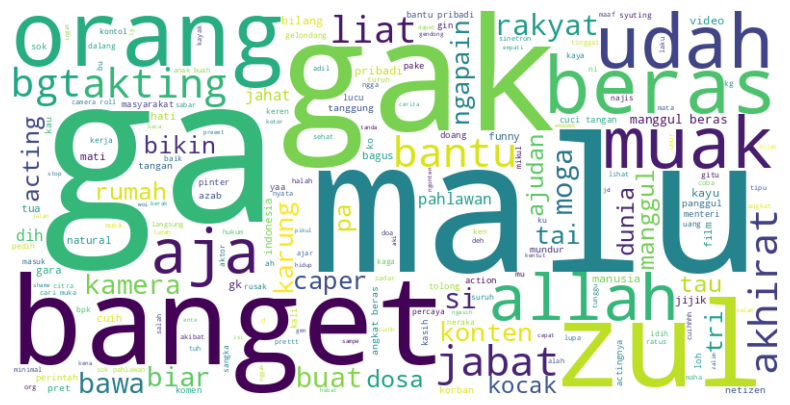

In [104]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Memuat data dari file CSV
df = pd.read_csv('data_gabungan_cleaned.csv')  # Ganti 'path_to_your_file.csv' dengan jalur file data Anda

# Gabungkan semua teks dalam kolom 'cleaned_komen' menjadi satu string besar
text = " ".join(judul for judul in df['stemmed_komen'].dropna())  # Pastikan tidak ada nilai NaN



# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove axis
plt.show()

**VISUALISASI KATA KUNCI TERBANYAK (WORDCLOUD)**

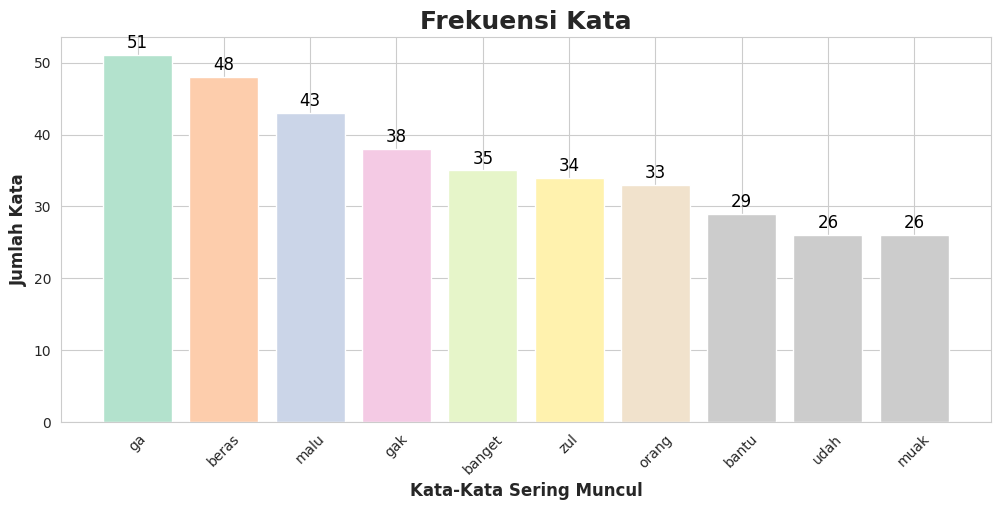

In [103]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

text = " ".join(judul for judul in df['stemmed_komen'].dropna())


tokens = [word for word in text.split() if word not in stop_words]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)

# Menggunakan palet warna lebih soft
colors = plt.cm.Pastel2(range(len(word)))

# Membuat plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 1.6 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

# Menampilkan plot
plt.show()

**LABELING DATA (POSITIF, NEGATIF, NETRAL) LEXICON BASED**

In [76]:
# Unduh kamus leksikon positif dan negatif dari GITHUB
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep='\t', header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep='\t', header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count

        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"

In [77]:
# Tentukan sentimen dan skor untuk setiap ulasan
df[['Score', 'label']] = df['stemmed_komen'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasilnya
df.head(10)

,link user,user,komen,likes,tanggal_absolut,cleaned_komen,stemmed_komen,tokens,link,replies,Score,label
0,https://www.instagram.com/awbimax/,awbimax,Caper banget!,667,2025-12-02,caper banget,caper banget,"['caper', 'banget']",NaN,NaN,1,Positif
1,https://www.instagram.com/meysna__/,meysna__,Preeeetttttt,51,2025-12-03,preeeetttttt,preeeetttttt,['preeeetttttt'],NaN,NaN,0,Netral
2,https://www.instagram.com/choqi_isyraqi/,choqi_isyraqi,"Mau tanya, kalau jadi pejabat kan ada cek kese...",1038,2025-12-02,pejabat cek kesehatan ya sempet dirontgen gak ...,jabat cek sehat ya sempet rontgen gak ya ngece...,"['jabat', 'cek', 'sehat', 'ya', 'sempet', 'ron...",NaN,NaN,0,Netral
3,https://www.instagram.com/deasyfillah/,deasyfillah,Pak kita udh pinter pa…. Bapa yang belum,29,2025-12-03,udh pinter pa bapa,udh pinter pa bapa,"['udh', 'pinter', 'pa', 'bapa']",NaN,NaN,0,Netral
4,https://www.instagram.com/pendakiindonesia/,pendakiindonesia,Hidupmu tenang pak? Tenteram? Yakin?,430,2025-12-02,hidupmu tenang tenteram,hidup tenang tenteram,"['hidup', 'tenang', 'tenteram']",NaN,NaN,0,Netral
5,https://www.instagram.com/anindythaarsa/,anindythaarsa,Merindinkk udah ah pak malu.,23,2025-12-03,merindinkk udah ah malu,merindinkk udah ah malu,"['merindinkk', 'udah', 'ah', 'malu']",NaN,NaN,0,Netral
6,https://www.instagram.com/fianiadila/,fianiadila,"Buu jangan percaya buu, itu lagi acting🙏🏻",36,2025-12-02,buu percaya buu acting,buu percaya buu acting,"['buu', 'percaya', 'buu', 'acting']",NaN,NaN,1,Positif
7,https://www.instagram.com/yogitaama/,yogitaama,Keren bgt pak yg bikin konten ini sampe bikin ...,25,2025-12-03,keren bgt yg bikin konten sampe bikin bpk bawa...,keren bgt yg bikin konten sampe bikin bpk bawa...,"['keren', 'bgt', 'yg', 'bikin', 'konten', 'sam...",NaN,NaN,3,Positif
8,https://www.instagram.com/ekorore/,ekorore,Pemeran aktor terbaik jatuh kepadaaaaaaaaaaaaa...,36,2025-12-02,pemeran aktor terbaik jatuh kepadaaaaaaaaaaaaa...,per aktor baik jatuh kepadaaaaaaaaaaaaaaaaa,"['per', 'aktor', 'baik', 'jatuh', 'kepadaaaaaa...",NaN,NaN,0,Netral
9,https://www.instagram.com/rdhrmdhn11/,rdhrmdhn11,Foto sama gelondongan kayunya mana pak?,700,2025-12-02,foto gelondongan kayunya,foto gelondong kayu,"['foto', 'gelondong', 'kayu']",NaN,NaN,1,Positif


**VISUALISASI JUMLAH SENTIMEN PUBLIK**

/tmp/ipython-input-664524484.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette="pastel")


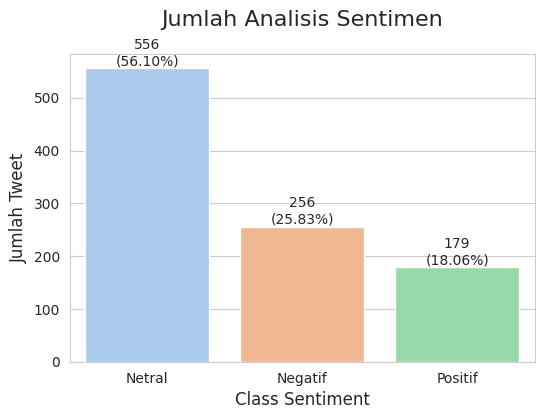

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = df['label'].value_counts()
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette="pastel")
plt.title("Jumlah Analisis Sentimen", fontsize=16, pad=20)
plt.xlabel("Class Sentiment", fontsize=12)
plt.ylabel("Jumlah Tweet", fontsize=12)

total = len(df['label'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('labeling_data.csv', index=False)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991 entries, 0 to 990
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   link user        776 non-null    object
 1   user             991 non-null    object
 2   komen            991 non-null    object
 3   likes            991 non-null    int64 
 4   tanggal_absolut  991 non-null    object
 5   cleaned_komen    991 non-null    object
 6   stemmed_komen    991 non-null    object
 7   tokens           991 non-null    object
 8   link             215 non-null    object
 9   replies          46 non-null     object
 10  Score            991 non-null    int64 
 11  label            991 non-null    object
dtypes: int64(2), object(10)
memory usage: 93.0+ KB


In [102]:
label_count = df['label'].value_counts()
label_count

,count
label,
Netral,556
Negatif,256
Positif,179


**WORLDCLOUD LABEL POSITIF**

In [80]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Daftar stopwords tambahan yang ingin dikecualikan
stopwords = set(STOPWORDS)
stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue',
    'kak', 'tan', 'ajar', 'dan', 'di', 'ke', 'sih',
    'dari', 'adalah', 'yang', 'untuk', 'dengan', 'pada', 'ini'
])

# Fungsi untuk membuat word cloud
def generate_wordcloud(text, title):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stopwords,
        max_words=100,
        colormap='tab20'
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.show()

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = df[df['label'] == 'Netral']['stemmed_komen'].str.cat(sep=' ')
sentimen_Negative = df[df['label'] == 'Negatif']['stemmed_komen'].str.cat(sep=' ')
sentimen_Positive = df[df['label'] == 'Positif']['stemmed_komen'].str.cat(sep=' ')

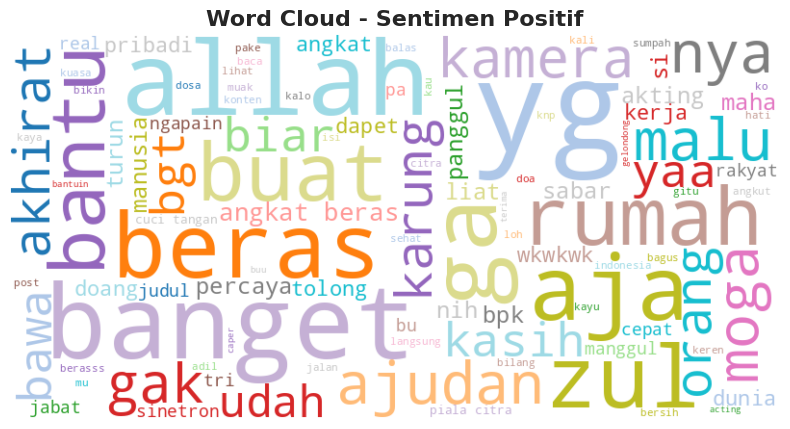

In [81]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Positive, "Word Cloud - Sentimen Positif")

**WORLDCLOUD LABEL NEGATIF**

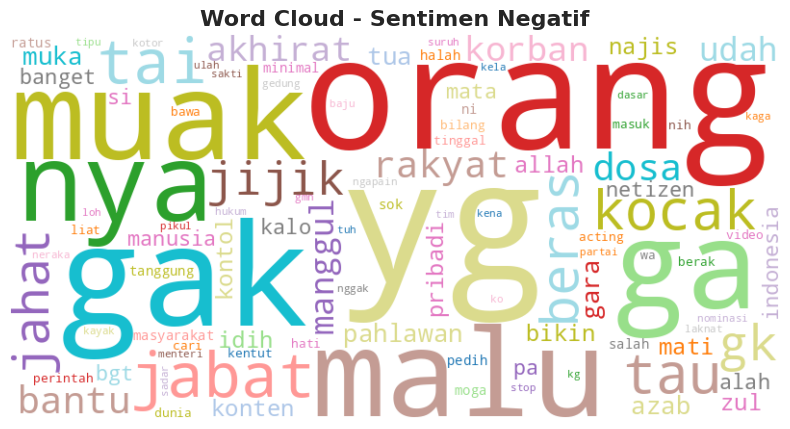

In [82]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Negative, "Word Cloud - Sentimen Negatif")

**WORLDCLOUD LABEL NETRAL**

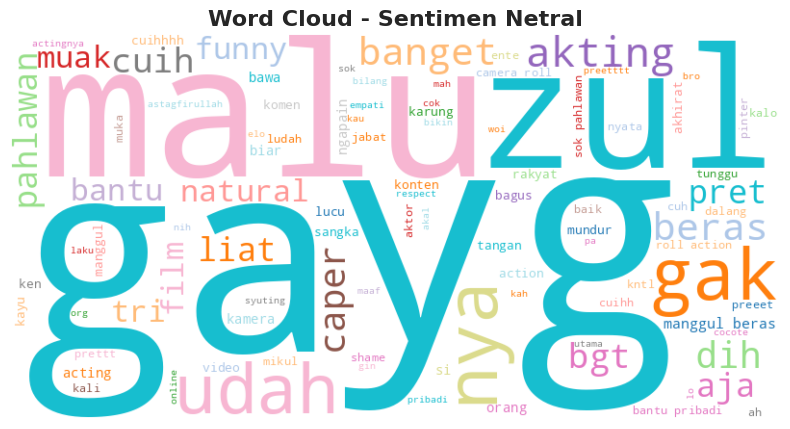

In [83]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Neutral, "Word Cloud - Sentimen Netral")

**FEATURE EXTRACTION**

In [84]:
df_list = df['stemmed_komen'].tolist()
print(df_list)

['caper banget', 'preeeetttttt', 'jabat cek sehat ya sempet rontgen gak ya ngecek hati', 'udh pinter pa bapa', 'hidup tenang tenteram', 'merindinkk udah ah malu', 'buu percaya buu acting', 'keren bgt yg bikin konten sampe bikin bpk bawak beras karung hahhahahahaha karung doang ajudan orang nya gk bantuin angkat beras', 'per aktor baik jatuh kepadaaaaaaaaaaaaaaaaa', 'foto gelondong kayu', 'ngapain manggul karung manggul kayu glondongan', 'sibuk ngonten anjir', 'mic kecil liat', 'yakali tri ngangkat beras ngapain atuh tugas protokol kronikroninya wkwk', 'ludahin cuih cuih cuihh', 'gimmicknya gak kena pa', 'ga diludahin bu', 'its not funny kocak', 'jujur ken muntah', 'terima kasih bantu baik peduli zul', 'disgusting', 'piala citra dapet nih', 'takedown take ulang approval client', 'pemcitraan zulhas anjeng manusia laknat binatang', 'bilang orang orang gak tolol pikir kntlllll', 'wkwkwk', 'prettt', 'nyeyeyeyyeyw', 'binatang', 'tembelek singa', 'biar liat kerja ya bawa beras pdhl ajudan ga 

In [85]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Isi nilai NaN dengan string kosong
df['stemmed_komen'] = df['stemmed_komen'].fillna('')

# Buat list dari kolom 'steming_data'
df_list = df['stemmed_komen'].tolist()

# Buat objek TfidfVectorizer
df_tfidf = TfidfVectorizer()

# Lakukan transformasi fitur
X = df_tfidf.fit_transform(df_list)

print('Feature Extraction Selesai!!!')
print('===== Bentuk Transformasi Feature Extraction =====')
print(X.shape)

# Dapatkan nama fitur (kata-kata unik)
feature_names = df_tfidf.get_feature_names_out()

# Hitung total skor TF-IDF untuk setiap term (kata)
tfidf_sums = X.sum(axis=0)

# Buat DataFrame untuk menampilkan hasil
tfidf_df = pd.DataFrame({
    'term': feature_names,
    'tfidf_sum': tfidf_sums.tolist()[0]
})

# Urutkan berdasarkan skor TF-IDF terbesar
tfidf_df = tfidf_df.sort_values('tfidf_sum', ascending=False)

print("\n==== Top 20 Terms by Total TF-IDF Score ====")
print(tfidf_df.head(20))

print("\n==== IDF Values ====")
idf_values = df_tfidf.idf_
idf_df = pd.DataFrame({
    'Term': feature_names,
    'IDF': idf_values
})
print(idf_df.head(20))

print("\n==== TF-IDF values for the first 5 documents ====")
for i in range(min(5, len(df_list))):
    first_document_tfidf = pd.DataFrame(
        X[i].T.todense(),
        index=feature_names,
        columns=["TF-IDF"]
    )
    print(f"\nDocument {i+1} TF-IDF Values:")
    print(first_document_tfidf.sort_values("TF-IDF", ascending=False).head(10))

Feature Extraction Selesai!!!
===== Bentuk Transformasi Feature Extraction =====
(991, 1825)

==== Top 20 Terms by Total TF-IDF Score ====
        term  tfidf_sum
987     malu  16.452246
1074    muak  16.243540
1802      yg  16.186880
1784      ya  14.100459
495       ga  13.015684
205    beras  12.557453
155   banget  11.318446
505      gak  11.253659
1813     zul  10.623014
396      dih  10.286237
1215     nya   9.761069
958       lu   9.661029
161    bantu   9.460396
48    akting   9.210687
1257   orang   9.178143
1603     tai   8.688674
226      bgt   7.863408
1381    pret   7.642503
28       aja   7.539430
357     cuih   7.418700

==== IDF Values ====
         Term       IDF
0     aaapaaa  7.206576
1      aamiin  6.801111
2       abadi  6.801111
3     abangda  7.206576
4        abis  7.206576
5      abistu  7.206576
6        abiz  7.206576
7       acara  7.206576
8        aceh  7.206576
9      acting  5.414816
10  actingnya  5.820282
11     action  5.501828
12    actions  7.206576

In [86]:
y = df['label']
print(y)

0      Positif
1       Netral
2       Netral
3       Netral
4       Netral
        ...   
986    Positif
987    Negatif
988    Negatif
989    Negatif
990     Netral
Name: label, Length: 991, dtype: object


In [87]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4037 stored elements and shape (991, 1825)>
  Coords	Values
  (0, 300)	0.7799881619905273
  (0, 155)	0.6257942690330738
  (1, 1369)	1.0
  (2, 705)	0.24965842351966624
  (2, 313)	0.3668812699374751
  (2, 1498)	0.31095175837279987
  (2, 1784)	0.4123215849800037
  (2, 1503)	0.3668812699374751
  (2, 1448)	0.3668812699374751
  (2, 505)	0.2197346538592521
  (2, 1151)	0.3668812699374751
  (2, 599)	0.29030983975699715
  (3, 1718)	0.5181749461589737
  (3, 1351)	0.4736547875629525
  (3, 1267)	0.46303171561724576
  (3, 165)	0.5410614546651693
  (4, 615)	0.5252178722181018
  (4, 1653)	0.6017250978240353
  (4, 1654)	0.6017250978240353
  (5, 1041)	0.6406833540074818
  (5, 1717)	0.4092974678299124
  (5, 22)	0.5293094659651006
  (5, 987)	0.37660577792366046
  (6, 287)	0.8731122334269261
  (6, 1332)	0.3606669090995344
  :	:
  (986, 1684)	0.33606943659394417
  (986, 274)	0.3037566076627921
  (986, 1454)	0.6353631382713183
  (986, 1483)	0.4161

**KLASIFIKASI MODEL MACHINE LEARNING**

In [91]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

Jumlah data training (X_train): 792
Jumlah data testing (X_test): 199


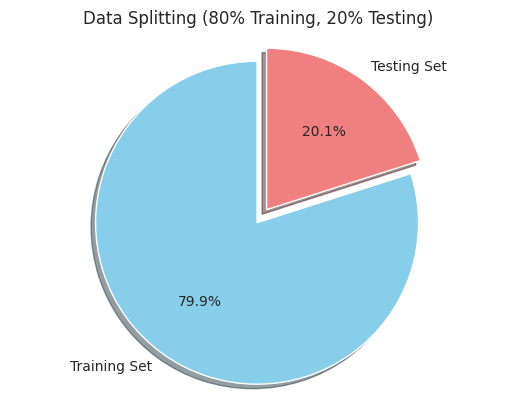

In [92]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting datasets
print("Jumlah data training (X_train):", X_train.shape[0])
print("Jumlah data testing (X_test):", X_test.shape[0])

# Visualize the data split
import matplotlib.pyplot as plt

train_size = X_train.shape[0]
test_size = X_test.shape[0]
total_size = train_size + test_size

labels = ['Training Set', 'Testing Set']
sizes = [train_size, test_size]
colors = ['skyblue', 'lightcoral']
explode = (0.1, 0)  # explode 1st slice

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Data Splitting (80% Training, 20% Testing)')
plt.show()


Training and evaluating: Logistic Regression
Accuracy: 0.6281
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.92      0.24      0.38        51
      Netral       0.59      0.97      0.74       107
     Positif       0.82      0.22      0.35        41

    accuracy                           0.63       199
   macro avg       0.78      0.48      0.49       199
weighted avg       0.72      0.63      0.56       199



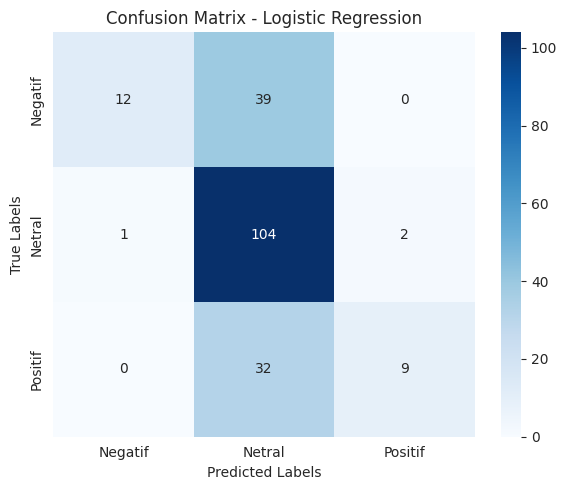


Training and evaluating: Decision Tree
Accuracy: 0.7136
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.79      0.53      0.64        51
      Netral       0.72      0.87      0.78       107
     Positif       0.63      0.54      0.58        41

    accuracy                           0.71       199
   macro avg       0.71      0.65      0.67       199
weighted avg       0.72      0.71      0.70       199



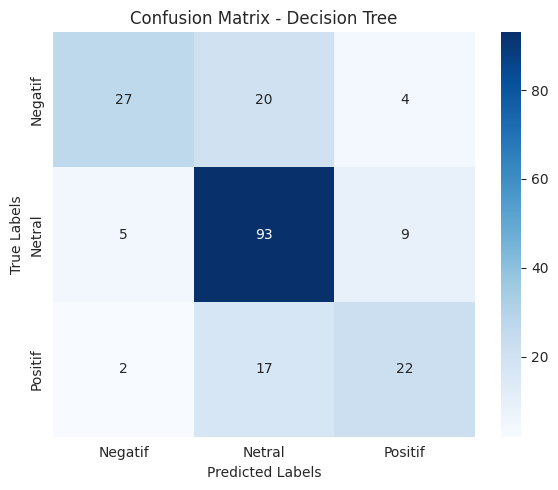


Training and evaluating: Random Forest
Accuracy: 0.6834
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.91      0.39      0.55        51
      Netral       0.64      0.95      0.77       107
     Positif       0.78      0.34      0.47        41

    accuracy                           0.68       199
   macro avg       0.78      0.56      0.60       199
weighted avg       0.74      0.68      0.65       199



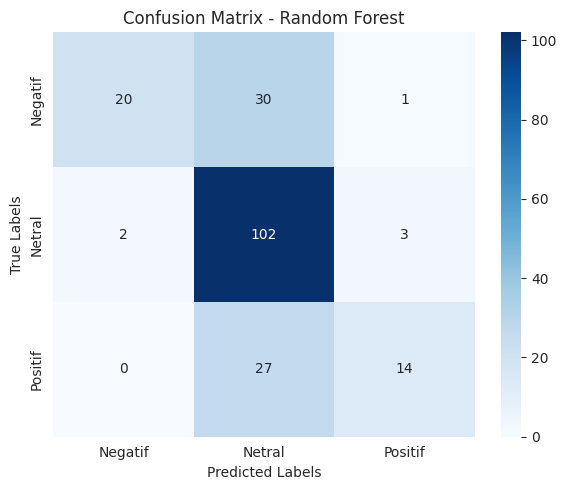


Training and evaluating: SVM
Accuracy: 0.7035
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.91      0.41      0.57        51
      Netral       0.66      0.96      0.78       107
     Positif       0.84      0.39      0.53        41

    accuracy                           0.70       199
   macro avg       0.80      0.59      0.63       199
weighted avg       0.76      0.70      0.67       199



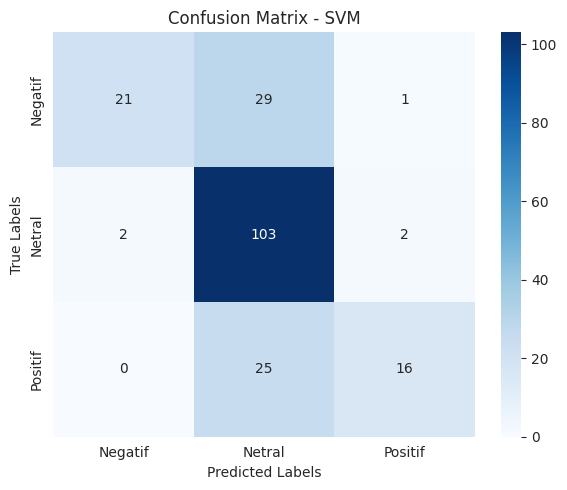


Training and evaluating: KNN
Accuracy: 0.5930
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.60      0.47      0.53        51
      Netral       0.59      0.85      0.70       107
     Positif       0.60      0.07      0.13        41

    accuracy                           0.59       199
   macro avg       0.60      0.46      0.45       199
weighted avg       0.60      0.59      0.54       199



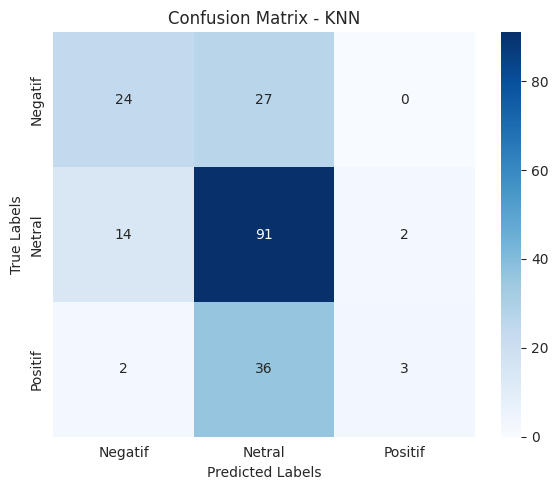


Training and evaluating: Naive Bayes
Accuracy: 0.6080
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.93      0.25      0.40        51
      Netral       0.58      0.99      0.73       107
     Positif       1.00      0.05      0.09        41

    accuracy                           0.61       199
   macro avg       0.84      0.43      0.41       199
weighted avg       0.76      0.61      0.51       199



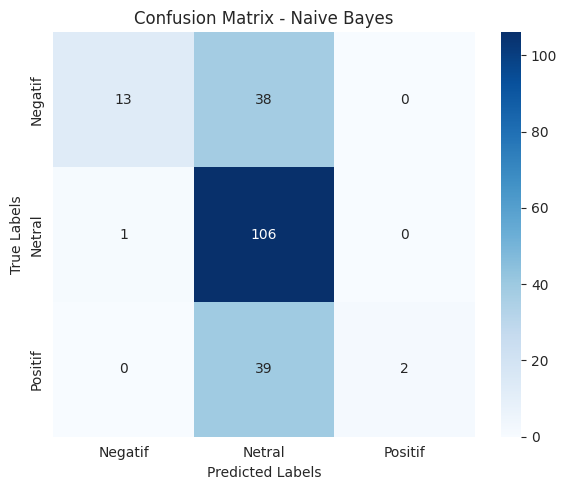


RINGKASAN AKHIR: PERBANDINGAN MODEL
Logistic Regression  | Accuracy: 0.6281
Decision Tree        | Accuracy: 0.7136
Random Forest        | Accuracy: 0.6834
SVM                  | Accuracy: 0.7035
KNN                  | Accuracy: 0.5930
Naive Bayes          | Accuracy: 0.6080


In [99]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Baca data (ganti nama file sesuai kebutuhan)
df = pd.read_csv('labeling_data.csv')

# 2. Siapkan fitur (X) dan target (y)
# Misal: X = kolom teks (cleaned_komen), y = kolom sentimen (positif/negatif/netral)
X = df['cleaned_komen']  # → ini string, harus diubah jadi numerik!
y = df['label']      # → pastikan ini sudah ada dan berisi 'positif', 'negatif', 'netral'

# 3. Ubah teks jadi vektor numerik (contoh: TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_vec = vectorizer.fit_transform(X)

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)

# 5. Definisikan classifier yang ingin diuji
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': MultinomialNB()
}

# 6. Train & evaluate setiap classifier
results = {}

for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Training and evaluating: {name}")
    print(f"{'='*50}")

    # Train
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # Simpan hasil
    results[name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': cm
    }

    # Tampilkan hasil
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=clf.classes_, yticklabels=clf.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()

# 7. Ringkasan akhir
print("\n" + "="*60)
print("RINGKASAN AKHIR: PERBANDINGAN MODEL")
print("="*60)
for name, res in results.items():
    print(f"{name:20} | Accuracy: {res['accuracy']:.4f}")

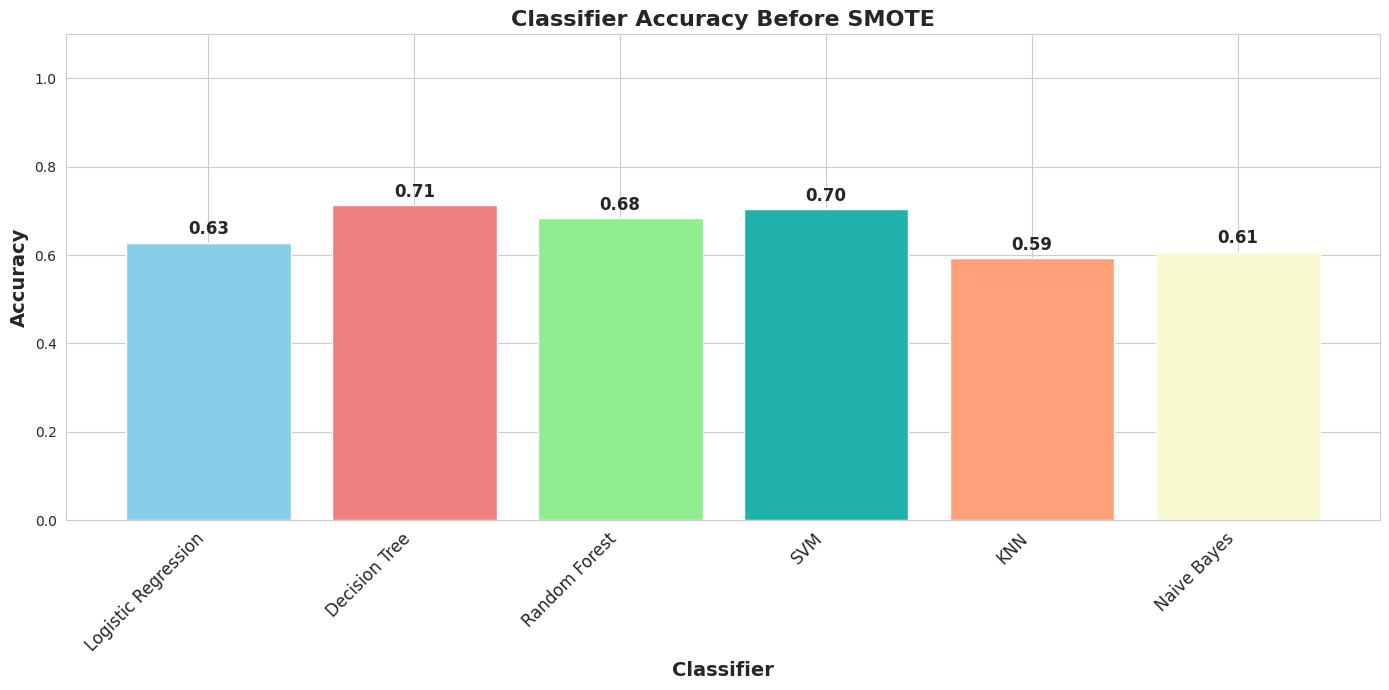

In [100]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming 'results' dictionary is defined from previous code
classifiers = list(results.keys())
accuracy_before = [results[name]['accuracy'] for name in classifiers]

# Improved Plotting
plt.figure(figsize=(14, 7))  # Slightly larger figure for better readability
bars = plt.bar(classifiers, accuracy_before, color=['skyblue', 'lightcoral', 'lightgreen', 'lightseagreen', 'lightsalmon', 'lightgoldenrodyellow'])
plt.xlabel("Classifier", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy", fontsize=14, fontweight='bold')
plt.title("Classifier Accuracy Before SMOTE", fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)  # Set y-axis limit
plt.xticks(rotation=45, ha='right', fontsize=12)  # Adjust font size and rotation

# Annotate bars with accuracy values
for bar, acc in zip(bars, accuracy_before):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{acc:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()  # Ensure labels are not cut off
plt.show()

In [101]:
def count_rows_csv(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        return sum(1 for line in f) - 1  # -1 untuk header

n1 = count_rows_csv('instagram (berwarna) rabu 08.30.csv')
n2 = count_rows_csv('instagram (tidak berwarna) rabu 09.00.csv')
total = n1 + n2

print(f"File 1: {n1} baris")
print(f"File 2: {n2} baris")
print(f"Total: {total} baris")

File 1: 1031 baris
File 2: 1045 baris
Total: 2076 baris
